In [ ]:
Challenge ONE: Telecom X - análisis de evasión de clientes
Ruben Vargas
	•	Problema: alta tasa de cancelación (Churn).
	•	Objetivo: preparar datos + análisis exploratorio + insights.


In [3]:
#importar librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
#carga del archivo e identificacion de anidacion
url= "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
df_raw=pd.read_json(url)
df_raw.head()
df_raw.iloc[0]

,0
customerID,0002-ORFBO
Churn,No
customer,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part..."
phone,"{'PhoneService': 'Yes', 'MultipleLines': 'No'}"
internet,"{'InternetService': 'DSL', 'OnlineSecurity': '..."
account,"{'Contract': 'One year', 'PaperlessBilling': '..."


In [5]:
#normalizacion del archivo anidado
customer = pd.json_normalize(df_raw["customer"])
phone = pd.json_normalize(df_raw["phone"])
internet = pd.json_normalize(df_raw["internet"])
account = pd.json_normalize(df_raw["account"])
df_base = df_raw.drop(columns=["customer","phone","internet","account"])
df = pd.concat([df_base, customer, phone, internet, account], axis=1)
df["Charges.Total"] = pd.to_numeric(df["Charges.Total"], errors="coerce")
df = df.dropna()
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7256 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7256 non-null   object 
 1   Churn             7256 non-null   object 
 2   gender            7256 non-null   object 
 3   SeniorCitizen     7256 non-null   int64  
 4   Partner           7256 non-null   object 
 5   Dependents        7256 non-null   object 
 6   tenure            7256 non-null   int64  
 7   PhoneService      7256 non-null   object 
 8   MultipleLines     7256 non-null   object 
 9   InternetService   7256 non-null   object 
 10  OnlineSecurity    7256 non-null   object 
 11  OnlineBackup      7256 non-null   object 
 12  DeviceProtection  7256 non-null   object 
 13  TechSupport       7256 non-null   object 
 14  StreamingTV       7256 non-null   object 
 15  StreamingMovies   7256 non-null   object 
 16  Contract          7256 non-null   object 
 17  

In [8]:
#EDA
df["Churn"] = df["Churn"].str.strip()
df["Churn"].value_counts()
df = df[df["Churn"] != ""]
df["Churn"].value_counts(normalize=True)


,proportion
Churn,
No,0.734215
Yes,0.265785


In [9]:
#analisis por duracion de contrato
df.groupby("Contract")["Churn"].value_counts(normalize=True)

Contract        Churn
Month-to-month  No       0.572903
                Yes      0.427097
One year        No       0.887228
                Yes      0.112772
Two year        No       0.971513
                Yes      0.028487
Name: proportion, dtype: float64

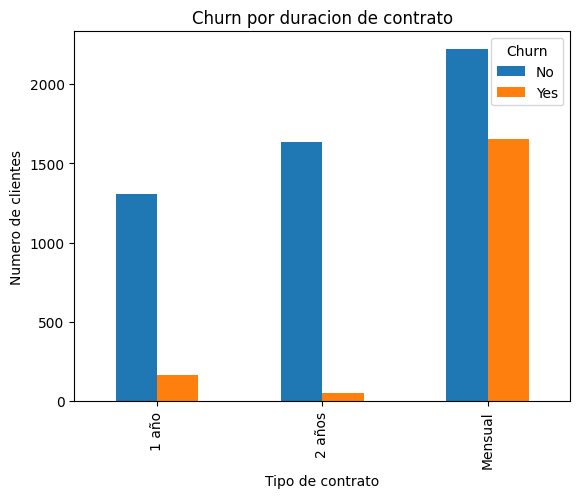

In [12]:
#visualizacion churn vs contrato
df["Contract"] = df["Contract"].replace({
    "Two year": "2 años",
    "One year": "1 año",
    "Month-to-month": "Mensual"
})
df.groupby("Contract")["Churn"].value_counts().unstack().plot(kind="bar")
plt.title("Churn por duracion de contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Numero de clientes")
plt.show()

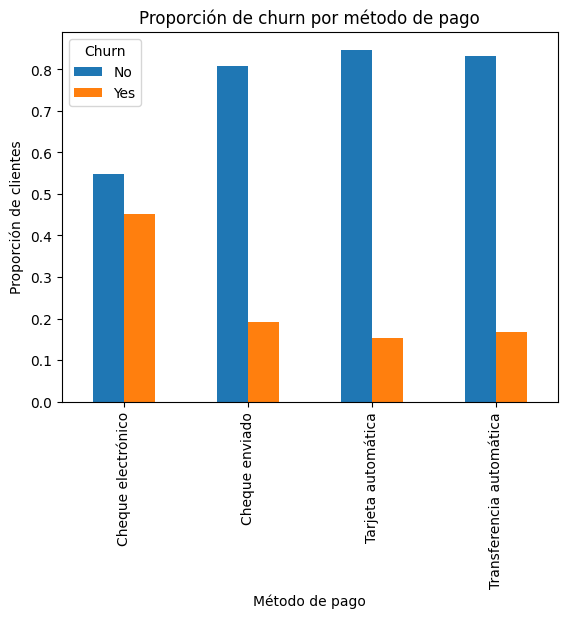

In [20]:
#visualizacion churn vs tipo de pago
df["PaymentMethod"] = df["PaymentMethod"].replace({
    "Electronic check": "Cheque electrónico",
    "Mailed check": "Cheque",
    "Bank transfer (automatic)": "Transferencia automática",
    "Credit card (automatic)": "Tarjeta de crédito"
})
df.groupby("PaymentMethod")["Churn"].value_counts(normalize=True).unstack().plot(kind="bar")

plt.title("Proporción de churn por método de pago")
plt.xlabel("Método de pago")
plt.ylabel("Proporción de clientes")

plt.show()

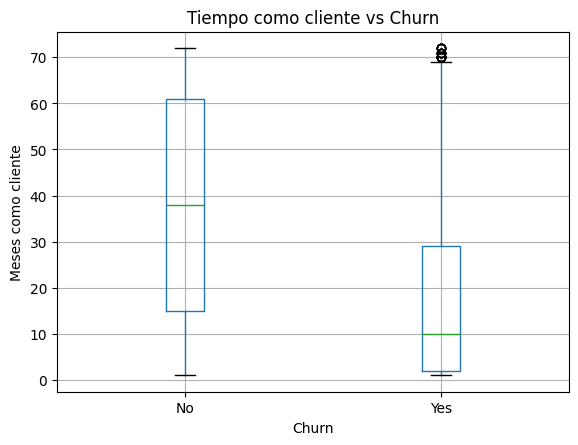

In [21]:
#visualizacion churn vs tiempo como cliente
df.boxplot(column="tenure", by="Churn")

plt.title("Tiempo como cliente vs Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Meses como cliente")

plt.show()

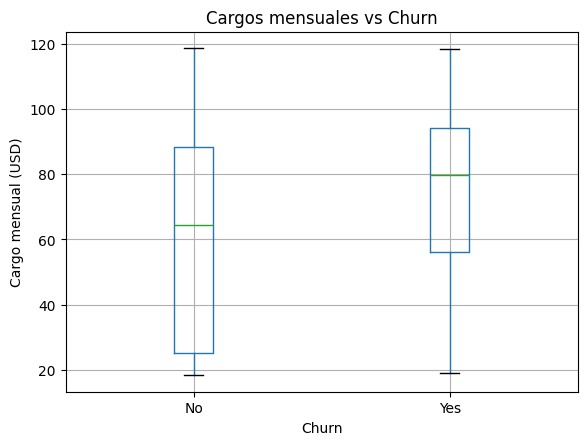

In [23]:
#visualizacion churn vs cargo mensual
df.boxplot(column="Charges.Monthly", by="Churn")

plt.title("Cargos mensuales vs Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Cargo mensual (USD)")

plt.show()

**Conclusiones**

El análisis exploratorio del dataset permitió identificar varios factores asociados con la cancelación del servicio citado a continuacion:


1. **Tipo de contrato**

Los clientes con contratos mensuales presentan la mayor tasa de cancelación frente a los contratos de uno o dos años, lo que sugiere incentivar contratos de mayor duración para favorecen la retención de los clientes.

2. **Método de pago**

El cheque electrónico como metodo de pago presenta una proporción significativamente mayor de cancelación en comparación con los otros metodos.

3. **Antigüedad del cliente**

Los clientes con menor tiempo en la empresa tienden a cancelar con mayor frecuencia.

4. **Cargos mensuales**

Los clientes que tienen cargos mensuales más elevados tienden a cancelar con mayor frecuencia, lo que sugiere que el costo del servicio puede influir en la decisión de abandono.

**Recomendaciones**

A partir del análisis realizado se sugieren las siguientes acciones para reducir la tasa de churn:

	•	Incentivar contratos de mayor duración, ya que presentan menor tasa de cancelación.
	•	Promover métodos de pago automáticos para mejorar la retención de clientes.
	•	Implementar estrategias de retención para clientes nuevos, especialmente durante los primeros meses.
	•	Evaluar la estructura de precios y paquetes de servicio para clientes con cargos mensuales elevados.